In [1]:
import pandas as pd
import numpy as np
#from prophet import Prophet

import matplotlib.pyplot as plt
%matplotlib inline
import datetime
from datetime import timedelta



In [2]:
df_datos = pd.read_csv('Treated_csv/entries_all.csv')

In [3]:
df_datos.head()

,Unnamed: 0,Entrada,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion
0,0,2010-01/0001-01,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados
1,2,2010-01/0001-02,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados
2,7,2010-01/0001-03,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales
3,21,2010-01/0001-04,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos
4,22,2010-01/0001-05,2010-01-01,F,64,Europa,Alemania,NaN,Pie,Religioso,Frances-Camino de,Astorga,Empleados


In [4]:
df_datos = df_datos.drop(columns='Unnamed: 0')

In [5]:
df_datos = df_datos.drop(columns='Entrada')
df_datos.head()

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados
1,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados
2,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales
3,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos
4,2010-01-01,F,64,Europa,Alemania,NaN,Pie,Religioso,Frances-Camino de,Astorga,Empleados


In [6]:
df_datos = df_datos.drop(columns='Autonomia')



In [7]:
mask =df_datos.Profesion.isna()

In [8]:
df_datos.Profesion = df_datos.Profesion.fillna('Otros')

In [9]:
df_datos.Profesion.unique()

array(['Jubilados', 'Liberales', 'Tecnicos', 'Empleados', 'Profesores',
       'Estudiantes', 'Agricultores', 'Obreros', 'Funcionarios',
       'Sacerdotes', 'Amas de Casa', 'Parados', 'Directivos',
       'Religiosas/os', 'Artistas', 'Deportistas', 'Marinos', 'Otros'],
      dtype=object)

In [10]:
mask_cont = df_datos.Continente.notna()

In [11]:
df_datos[mask_cont]

,Fecha,Sexo,Edad,Continente,Pais,Medio,Motivo,Camino,Origen,Profesion
0,2010-01-01,M,58,Europa,España,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados
1,2010-01-01,M,62,Europa,España,Pie,Religioso,Frances-Camino de,Sarria,Jubilados
2,2010-01-01,M,54,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales
3,2010-01-01,F,44,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos
4,2010-01-01,F,64,Europa,Alemania,Pie,Religioso,Frances-Camino de,Astorga,Empleados
...,...,...,...,...,...,...,...,...,...,...
3288646,2022-12-31 16:45:23,M,56,Europa,Portugal,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,Otros
3288647,2022-12-31 16:45:23,M,55,Europa,Portugal,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,Otros
3288648,2022-12-31 16:45:23,M,28,Europa,Portugal,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,Otros
3288649,2022-12-31 16:45:23,M,16,Europa,Portugal,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,Otros


In [12]:
df_datos = df_datos[mask_cont]

In [13]:
df_datos.reset_index(inplace=True)

In [14]:
df_datos = df_datos.drop(columns='index')

df_datos.head()

,Fecha,Sexo,Edad,Continente,Pais,Medio,Motivo,Camino,Origen,Profesion
0,2010-01-01,M,58,Europa,España,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados
1,2010-01-01,M,62,Europa,España,Pie,Religioso,Frances-Camino de,Sarria,Jubilados
2,2010-01-01,M,54,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales
3,2010-01-01,F,44,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos
4,2010-01-01,F,64,Europa,Alemania,Pie,Religioso,Frances-Camino de,Astorga,Empleados


In [15]:
df_datos.Fecha = pd.to_datetime(df_datos['Fecha'])

In [16]:
df_datos['Año'] = df_datos['Fecha'].dt.year
df_datos['Mes'] = df_datos['Fecha'].dt.month
df_datos['Dia'] = df_datos['Fecha'].dt.day
df_datos.head(3)



,Fecha,Sexo,Edad,Continente,Pais,Medio,Motivo,Camino,Origen,Profesion,Año,Mes,Dia
0,2010-01-01,M,58,Europa,España,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados,2010,1,1
1,2010-01-01,M,62,Europa,España,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,2010,1,1
2,2010-01-01,M,54,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,2010,1,1


In [17]:
df_datos.head(3)

,Fecha,Sexo,Edad,Continente,Pais,Medio,Motivo,Camino,Origen,Profesion,Año,Mes,Dia
0,2010-01-01,M,58,Europa,España,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados,2010,1,1
1,2010-01-01,M,62,Europa,España,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,2010,1,1
2,2010-01-01,M,54,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,2010,1,1


In [18]:
mask_sex = (df_datos['Sexo']== 'M') |(df_datos['Sexo']== 'F')


In [19]:
df_datos = df_datos[mask_sex]

In [20]:
df_datos.head()

,Fecha,Sexo,Edad,Continente,Pais,Medio,Motivo,Camino,Origen,Profesion,Año,Mes,Dia
0,2010-01-01,M,58,Europa,España,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados,2010,1,1
1,2010-01-01,M,62,Europa,España,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,2010,1,1
2,2010-01-01,M,54,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,2010,1,1
3,2010-01-01,F,44,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos,2010,1,1
4,2010-01-01,F,64,Europa,Alemania,Pie,Religioso,Frances-Camino de,Astorga,Empleados,2010,1,1


In [21]:
origen = pd.DataFrame(df_datos.Origen.unique())
origen.head()

,0
0,Resto Cantabria
1,Sarria
2,Ponferrada
3,Astorga
4,Braga


In [22]:
origen.to_csv('origen.csv')

In [23]:
df_datos.Origen.value_counts()

Sarria                    864064
S. Jean P. Port           318562
Tui                       201367
Oporto                    191064
Cebreiro                  126163
                           ...  
Xubia                          1
Villamoros de Mansilla         1
Oostkapelle                    1
Campobecerros                  1
Padron                         1
Name: Origen, Length: 498, dtype: int64

In [24]:
df_datos['Origen'] = [s.replace("Cast." , "Castilla") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("Resto " , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" - C.F." , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" - V.P." , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" - C.N" , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" - C.P." , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" Com." , "Comunidad") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" C.G.A." , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" C.G.R." , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" C.M.A." , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("(por Pobra de Burón)" , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" (por San Xoán de Padrón )" , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" (por Samos)" , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" (por San XII)" , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("C. León C.F." , "Castilla León") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" - O.C." , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" C. Ing" , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" C.Ing" , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("La Mesa" , "La Mesa, España") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("Hospital, España de Orbigo" , "Hospital, España") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" C.F." , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" C.Inv." , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace(" V.P." , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("C.G.A. resto de " , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("C.G.R." , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("C.G.A." , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("O.C." , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("C.G.A" , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("C.G.R" , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("de Portugal C.M.R." , "Portugal") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("R.Pais Vasco" , "Pais Vasco") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("otros" , "") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("R. Castilla León C.Inv" , "Reino de Castilla y León") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("de Extremadura" , "Extremadura") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("de Portugal" , "Portugal") for s in df_datos.Origen]
df_datos['Origen'] = [s.replace("La caridad" , "La caridad, España") for s in df_datos.Origen]

In [25]:
from geopy.geocoders import Nominatim
loc = Nominatim(user_agent="GetLoc")
 
# entering the location name
getLoc = loc.geocode("A Canda")
 
# printing address
print(getLoc.address)
 
# printing latitude and longitude
print("Latitude = ", getLoc.latitude)
print("Longitude = ", getLoc.longitude)

A Canda, A Mezquita, Viana, Ourense, Galicia, España
Latitude =  42.0392071
Longitude =  -6.9804032


In [26]:
from geopy.geocoders import Nominatim



In [7]:
cache ={}

In [24]:
cache



{'Sarria': 42.7784203,
 'O Cebreiro': 42.7188437,
 'Leon': 31.2715127,
 'Burgos': 42.343926,
 'Logroño': 42.4661196,
 'O Pedrouzo': 42.904007,
 'Palas de Rei': 42.8739125}

In [9]:
def latitude(texto):
    if texto in cache:
        return cache[texto]
    
    loc = Nominatim(user_agent="GetLoc")
    try: 
        # ingresar el nombre de la ubicación
        getLoc = loc.geocode(texto)
        if getLoc is not None:
            latitud = getLoc.latitude
            cache[texto] = latitud
            return latitud
        else:
            return None
    except:
        return None
        

In [25]:
import time
inicio = time.time()

# Código a medir
latitude('Paris')

fin = time.time()
print(fin-inicio)

0.35698509216308594


In [44]:
unique_vals = df_datos['Origen'].unique()
non_repeated_vals = unique_vals[df_datos['Origen'].value_counts() == 1]

print(non_repeated_vals)


['Mombuey' 'Montamarta' 'Los Santos de Maimona' 'Martiñan'
 'Markina-Xemein' 'Poladura de la Tercia' 'Almendralejo' 'Belesar'
 'Brujas' 'Lezama' 'Lobios ' 'Palmeira' 'Viloria de Rioja' 'Bustio'
 'El Acebo' 'Riego de Ambrós' 'Villamoros de Mansilla'
 'Villares de Órbigo' 'Ruitelán' 'Campobecerros' 'Silleiro' 'Tábara'
 'Porto do Cabo (Cedeira)' 'Morille' 'Fonfría ' 'Castildelgado'
 'Casar de Cáceres' 'San XII' 'Fuente de Cantos' 'Biduedo' 'Carballido'
 'Aguila del campo' 'Fuenterroble de Salvatierra' 'Monesterio' 'Boiro'
 'Población de Campos' 'Miño' 'Calzadilla de Tera' 'Villalval' 'Manjarín'
 'Arrés' 'Bexo' 'Carballo de Lor' 'San Andrés de Teixido' 'Ponte de sa'
 'Aldeanueva del Camino' 'Santiago da ria de abres' 'A Canda' 'Padron']


In [45]:
df_datos['Latitud'] = df_datos['Origen'].apply(latitude)

In [47]:
df_datos[df_datos['Latitud']== None]

,Fecha,Sexo,Edad,Continente,Pais,Medio,Motivo,Camino,Origen,Profesion,Año,Mes,Dia,Latitud


In [4]:
cache2= {}

In [5]:
def longitud(texto):
    if texto in cache2:
        return cache2[texto]
    
    loc = Nominatim(user_agent="GetLoc")
    try: 
        # ingresar el nombre de la ubicación
        getLoc = loc.geocode(texto)
        if getLoc is not None:
            longitude = getLoc.longitude
            cache2[texto] = longitude
            return longitude
        else:
            return None
    except:
        return None

In [138]:
df_datos['Longitud'] = df_datos['Origen'].apply(longitud)

In [139]:
len(cache)

472

In [140]:
len(cache2)

472

In [153]:
non_repeated_vals = unique_vals[df_datos['Origen'].value_counts() >1]

print(non_repeated_vals)

['Cantabria' 'Sarria' 'Ponferrada' 'Astorga' 'Braga' 'Ourense' 'Pamplona'
 'Tui' 'Lugo' 'Roncesvalles' 'Castilla León' 'Laza' 'Valença do Minho'
 'Cebreiro' 'Ferrol' 'Irún' 'León' 'Holanda' 'Oporto' 'Triacastela'
 'Logroño' 'Suiza' 'Oviedo' 'S. Jean P. Port' 'Frómista' 'Vilafranca'
 'Burgos' 'Asturias' 'Francia' 'Sevilla' 'Castilla La Mancha VP' 'Ribadeo'
 'Jaca' 'Granja de Moreruela' 'Alemania' 'Carrión de los Condes' 'Somport'
 'Abadin' 'Andalucia' 'Oviedo.' 'Vilalba' 'Lourenzá' 'Avilés' 'Le Puy'
 'Barcelona' 'Madrid' 'Salamanca' 'Sto. Domingo de la Calzada' 'Cadavo'
 'Samos' 'Zamora' 'Murcia' 'Xunqueira de Ambia' 'Com. Valenciana'
 'Polonia' 'Lourdes' 'Cáceres' 'Hospital de Orbigo' 'Reino Unido'
 'Portugal' 'París' 'Verín' 'Santander' 'Bilbao' 'Lisboa' 'Finisterra'
 'Estella' 'C. León' 'Ponte de Lima' 'Vega de Valcarce' 'Sahagún'
 'Canfranc' 'Vigo' 'Huelva' 'Malaga' 'Fonsagrada' 'Tineo' 'País Vasco.'
 'Valladolid' 'Cataluña' 'Montserrat' 'Puente la Reina'
 'Puebla de Sanabria' 'Chav

In [154]:
inicio = time.time()

# Código a medir
longitud('Sarria')

fin = time.time()
print(fin-inicio)

7.796287536621094e-05


In [155]:
inicio = time.time()
for ele in non_repeated_vals:
    longitud(ele)
fin = time.time()
print(fin-inicio)

6.599456787109375


In [156]:
df_datos.head()

,Fecha,Sexo,Edad,Continente,Pais,Medio,Motivo,Camino,Origen,Profesion,Año,Mes,Dia,Latitud,Longitud
0,2010-01-01,M,58,Europa,España,Bicicleta,Religioso,Norte-Camino de,Cantabria,Jubilados,2010,1,1,43.159566,-4.087838
1,2010-01-01,M,62,Europa,España,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,2010,1,1,42.778420,-7.414661
2,2010-01-01,M,54,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,2010,1,1,42.545412,-6.593872
3,2010-01-01,F,44,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos,2010,1,1,42.545412,-6.593872
4,2010-01-01,F,64,Europa,Alemania,Pie,Religioso,Frances-Camino de,Astorga,Empleados,2010,1,1,42.455356,-6.052903


In [157]:
df_datos.to_csv('Treated_csv/origin_all.csv')

In [158]:
df_datos['Longitud'] == None 

0          False
1          False
2          False
3          False
4          False
           ...  
3288644    False
3288645    False
3288646    False
3288647    False
3288648    False
Name: Longitud, Length: 3288648, dtype: bool

In [165]:
df_datos[df_datos['Latitud']> 50 ]

,Fecha,Sexo,Edad,Continente,Pais,Medio,Motivo,Camino,Origen,Profesion,Año,Mes,Dia,Latitud,Longitud
75,2010-01-03 00:00:00,M,54,Europa,Holanda,Pie,Religioso,Frances-Camino de,Holanda,Liberales,2010,1,3,52.243498,5.634323
308,2010-01-05 00:00:00,F,34,Europa,Alemania,Pie,Religioso,Frances-Camino de,Alemania,Religiosas/os,2010,1,5,51.163818,10.447831
346,2010-01-06 00:00:00,F,21,Europa,España,Pie,Religioso y otros,Norte-Camino de,Abadin,Estudiantes,2010,1,6,57.148243,-2.092809
347,2010-01-07 00:00:00,M,21,Europa,España,Pie,Religioso y otros,Norte-Camino de,Abadin,Estudiantes,2010,1,7,57.148243,-2.092809
348,2010-01-07 00:00:00,F,21,Europa,España,Pie,Religioso y otros,Norte-Camino de,Abadin,Estudiantes,2010,1,7,57.148243,-2.092809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3288112,2022-12-29 12:00:54,M,28,Europa,Alemania,Bicicleta,Religioso,Frances-Camino de,Holanda,Otros,2022,12,29,52.243498,5.634323
3288118,2022-12-29 13:05:44,M,59,Europa,Holanda,Pie,Religioso y otros,Frances-Camino de,Holanda,Otros,2022,12,29,52.243498,5.634323
3288119,2022-12-29 13:05:45,F,58,Europa,Holanda,Pie,Religioso y otros,Frances-Camino de,Holanda,Otros,2022,12,29,52.243498,5.634323
3288245,2022-12-30 13:14:33,M,64,Europa,Alemania,Pie,Religioso y otros,Frances-Camino de,Alemania,Otros,2022,12,30,51.163818,10.447831


In [2]:
df_origen = pd.read_csv('Treated_csv/origin_all.csv')

In [31]:
df_origen[df_origen['Longitud'] <35]

,Unnamed: 0,Fecha,Sexo,Edad,Continente,Pais,Medio,Motivo,Camino,Origen,Profesion,Año,Mes,Dia,Latitud,Longitud
0,0,2010-01-01,M,58,Europa,España,Bicicleta,Religioso,Norte-Camino de,Cantabria,Jubilados,2010,1,1,43.159566,-4.087838
1,1,2010-01-01,M,62,Europa,España,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,2010,1,1,42.778420,-7.414661
2,2,2010-01-01,M,54,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,2010,1,1,42.545412,-6.593872
3,3,2010-01-01,F,44,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos,2010,1,1,42.545412,-6.593872
4,4,2010-01-01,F,64,Europa,Alemania,Pie,Religioso,Frances-Camino de,Astorga,Empleados,2010,1,1,42.455356,-6.052903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3288643,3288644,2022-12-31 16:45:23,M,56,Europa,Portugal,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,Otros,2022,12,31,38.707751,-9.136592
3288644,3288645,2022-12-31 16:45:23,M,55,Europa,Portugal,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,Otros,2022,12,31,38.707751,-9.136592
3288645,3288646,2022-12-31 16:45:23,M,28,Europa,Portugal,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,Otros,2022,12,31,38.707751,-9.136592
3288646,3288647,2022-12-31 16:45:23,M,16,Europa,Portugal,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,Otros,2022,12,31,38.707751,-9.136592


In [12]:
from geopy.geocoders import Nominatim
import time




In [10]:
def incluir(texto):
    inicio = time.time()
    # Código a medir
    longitud(texto)
    latitude(texto)
    fin = time.time()
    print(fin-inicio)

In [17]:
incluir('Logroño')

0.7233970165252686


In [22]:
incluir('Palas de Rei')

0.8257851600646973


In [23]:
cache

{'Sarria': 42.7784203,
 'O Cebreiro': 42.7188437,
 'Leon': 31.2715127,
 'Burgos': 42.343926,
 'Logroño': 42.4661196,
 'O Pedrouzo': 42.904007,
 'Palas de Rei': 42.8739125}

In [54]:
mask = df_origen['Longitud'] < 7
mask2 = df_origen['Latitud'] > 35
mask3 = df_origen['Longitud'] > -15
mask4 = df_origen['Latitud'] < 46




In [55]:
df_filtrado = df_origen.loc[mask & mask2 & mask3 & mask4]


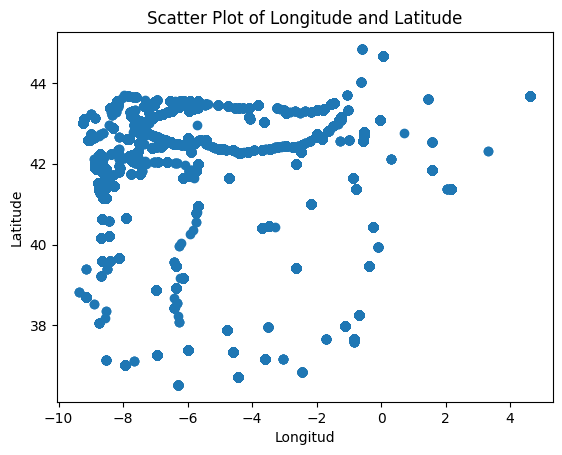

In [56]:
 import matplotlib.pyplot as plt

plt.scatter(df_filtrado['Longitud'], df_filtrado['Latitud'])
plt.xlabel('Longitud')
plt.ylabel('Latitude')
plt.title('Scatter Plot of Longitude and Latitude')
plt.show()


In [58]:
df_filtrado['Camino'].unique()

array(['Norte-Camino de', 'Frances-Camino de', 'Portugues-Camino',
       'Via de la Plata', 'Primitivo-Camino', 'Ingles-Camino',
       'Otros caminos', 'Costa Camino Portugues  ', 'Muxia-Finisterre',
       'Invierno de Camino', 'Muros - Noia Camino', 'Geira e Arrieiros',
       'Miñoto Ribeiro', 'Camino del Barbanza', 'Vía Céltica',
       'San Salvador', 'Camino del Mar', 'Camino olvidado', 'San Rosendo'],
      dtype=object)

In [60]:

df_filtrado['Camino'].value_counts()



Frances-Camino de           1887460
Portugues-Camino             567843
Norte-Camino de              186081
Primitivo-Camino             137963
Ingles-Camino                122218
Via de la Plata              109459
Costa Camino Portugues        88555
Otros caminos                  9608
Invierno de Camino             6766
Muxia-Finisterre               6030
Camino del Barbanza             919
Geira e Arrieiros               419
Miñoto Ribeiro                  396
Camino del Mar                  142
Muros - Noia Camino              66
Camino olvidado                  50
San Salvador                     43
Vía Céltica                       5
San Rosendo                       4
Name: Camino, dtype: int64